In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
import plotly.express as px

%matplotlib inline

In [2]:
test=pd.read_csv('../data/raw/df_final_experiment_clients.txt')
test.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [3]:
test.isna().sum()

client_id        0
Variation    20109
dtype: int64

In [4]:
test.duplicated().sum()

np.int64(0)

In [5]:
customer=pd.read_csv('../data/raw/df_final_demo.txt')
customer.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [6]:
web1=pd.read_csv('../data/raw/df_final_web_data_pt_1.txt')
web1.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [7]:
web2=pd.read_csv('../data/raw/df_final_web_data_pt_2.txt')
web2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [8]:
web_df=pd.concat([web1, web2])
web_df.duplicated().sum()

np.int64(10764)

In [9]:
web_df.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [10]:
web_df.shape

(755405, 5)

In [11]:
web_df=web_df.drop_duplicates()

In [12]:
web_df.isna().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [13]:
web_df.duplicated().sum()

np.int64(0)

In [14]:
web_df.shape

(744641, 5)

In [15]:
customer.shape

(70609, 9)

In [16]:
test.shape

(70609, 2)

In [17]:
customer_test= pd.merge(customer, test, on='client_id')
customer_test.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control


In [18]:
customer_test.duplicated().sum()

np.int64(0)

In [19]:
customer_test.isna().sum()

client_id               0
clnt_tenure_yr         14
clnt_tenure_mnth       14
clnt_age               15
gendr                  14
num_accts              14
bal                    14
calls_6_mnth           14
logons_6_mnth          14
Variation           20109
dtype: int64

In [20]:
customer_test.client_id.nunique()

70609

In [21]:
customer_test.loc[customer_test.isna().any(axis=1)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0,Control
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test
...,...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0,NaN
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0,NaN
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0,NaN
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0,NaN


In [22]:
experiment=pd.merge(web_df,customer_test, on='client_id', how='left')
experiment.head()

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test


# TEST CLIENTS KPI ANALYSIS

In [23]:

test_df=experiment[experiment['Variation'] == 'Test']

In [24]:
test_df.head(10)

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
5,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
6,9988021,580560515_7732621733,781255054_21935453173_531117,step_1,2017-04-17 15:17:01,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17 15:16:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05,22.0,274.0,34.5,M,2.0,36001.90,5.0,8.0,Test
9,8320017,39393514_33118319366,960651974_70596002104_312201,step_3,2017-04-05 13:09:43,22.0,274.0,34.5,M,2.0,36001.90,5.0,8.0,Test


In [25]:
test_df.isna().sum()

client_id            0
visitor_id           0
visit_id             0
process_step         0
date_time            0
clnt_tenure_yr      58
clnt_tenure_mnth    58
clnt_age            58
gendr               58
num_accts           58
bal                 58
calls_6_mnth        58
logons_6_mnth       58
Variation            0
dtype: int64

1. univariate: clients using customer df. Analyze age and other identifiers in clients. build a profile
2. test_df proportion of confirm 

## Univariate analysis: Client behavior analysis

Answer the following questions about demographics:

- Who are the primary clients using this online process?
- Are the primary clients younger or older, new or long-standing?

In [26]:
client_test = test_df.loc[test_df["Variation"] == "Test"]
client_test.client_id.nunique()

26968

In [27]:
client_test.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,1.766990e+05,176641.000000,176641.000000,176641.000000,176641.000000,1.766410e+05,176641.000000,176641.000000
mean,5.006661e+06,12.182025,152.227410,48.722216,2.253690,1.623231e+05,3.201986,6.242124
std,2.879014e+06,6.940522,82.955476,15.646423,0.532044,3.684109e+05,2.201277,2.186744
min,5.550000e+02,2.000000,33.000000,17.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,2.508453e+06,6.000000,82.000000,35.000000,2.000000,4.100530e+04,1.000000,4.000000
50%,5.061874e+06,11.000000,138.000000,50.500000,2.000000,6.929065e+04,3.000000,6.000000
75%,7.475920e+06,16.000000,193.000000,61.000000,2.000000,1.526703e+05,6.000000,9.000000
max,9.999832e+06,55.000000,669.000000,96.000000,7.000000,1.632004e+07,6.000000,9.000000


In [28]:
# gender analysis
gender_freq=client_test.gendr.value_counts()
gender_prop=client_test.gendr.value_counts(normalize=True)

display(gender_freq, gender_prop)

gendr
M    59288
U    59176
F    58169
X        8
Name: count, dtype: int64

gendr
M    0.335641
U    0.335007
F    0.329306
X    0.000045
Name: proportion, dtype: float64

In [29]:
# Age analysis: 
mean_age = client_test['clnt_age'].mean()
median_age = client_test['clnt_age'].median()
mode_age = client_test['clnt_age'].mode()[0]
var_age = client_test['clnt_age'].var()
std_age = client_test['clnt_age'].std()
min_age = client_test['clnt_age'].min()
max_age = client_test['clnt_age'].max()
range_age = max_age - min_age
quantiles_age = client_test['clnt_age'].quantile([0.25, 0.5, 0.75])

mean_age, median_age,mode_age, var_age, std_age, range_age, quantiles_age

(np.float64(48.72221624651129),
 np.float64(50.5),
 np.float64(62.5),
 np.float64(244.81056785996273),
 np.float64(15.646423484616628),
 np.float64(79.0),
 0.25    35.0
 0.50    50.5
 0.75    61.0
 Name: clnt_age, dtype: float64)

The Test group is mainly composed of middle-aged clients. The average and median ages are both around 47, indicating a balanced distribution centered in the late 40s. Although the most common age is 29.5, most clients fall between 33.5 and 59.5 years old, suggesting the primary client profile is not especially young but rather adult to older-middle-aged.

In [30]:
skewness_age = client_test['clnt_age'].skew()
kurtosis_age = client_test['clnt_age'].kurtosis()

skewness_age, kurtosis_age

(np.float64(-0.028902996684942162), np.float64(-0.9327549362076537))

The Test group’s age distribution is approximately symmetric, with only a very slight skew toward older clients. The negative kurtosis suggests that ages are relatively spread out across the sample, rather than heavily concentrated around one specific age. This supports the idea that the Test group is broadly middle-aged, with a wide age range.

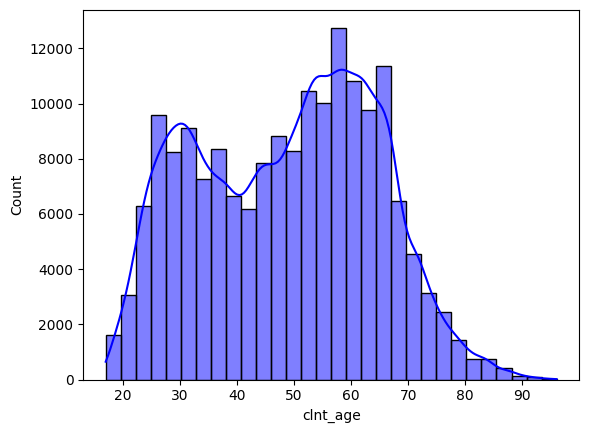

In [31]:
fig, axes = plt.subplots()
sns.histplot(client_test['clnt_age'], kde=True, bins=30, color="blue", ax=axes);
plt.show()

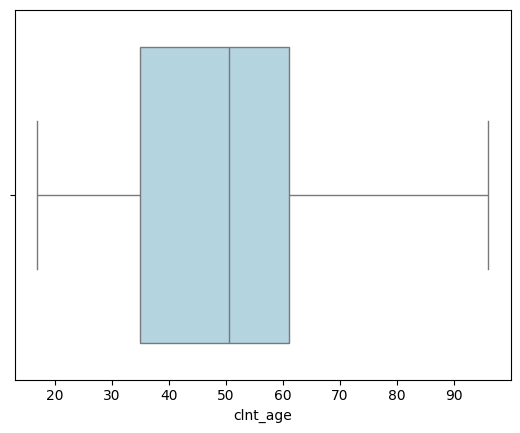

In [32]:
sns.boxplot(x = client_test['clnt_age'], color="lightblue");

This visualization confirms that there are indeed no outliers in the age. 

In [33]:
# new or long standing clients: 
mean_seniority = client_test['clnt_tenure_mnth'].mean()
median_seniority = client_test['clnt_tenure_mnth'].median()
mode_seniority = client_test['clnt_tenure_mnth'].mode()[0]
var_seniority = client_test['clnt_tenure_mnth'].var()
std_seniority = client_test['clnt_tenure_mnth'].std()
min_seniority = client_test['clnt_tenure_mnth'].min()
max_seniority = client_test['clnt_tenure_mnth'].max()
range_seniority = max_seniority - min_seniority
quantiles_seniority = client_test['clnt_tenure_mnth'].quantile([0.25, 0.5, 0.75])

mean_seniority, median_seniority,mode_seniority, var_seniority, std_seniority, range_seniority, quantiles_seniority

(np.float64(152.22741039735962),
 np.float64(138.0),
 np.float64(58.0),
 np.float64(6881.6109653778185),
 np.float64(82.95547580104534),
 np.float64(636.0),
 0.25     82.0
 0.50    138.0
 0.75    193.0
 Name: clnt_tenure_mnth, dtype: float64)

The Test group is mainly composed of long-standing clients. The average tenure is around 150 months, or 12.5 years, and the median is around 134 months, or 11.2 years. Since 75% of clients have been with the company for up to nearly 16 years, and even the first quartile is close to 7 years, this group appears to be mostly established rather than new customers.

In [34]:
skewness_seniority = client_test['clnt_tenure_mnth'].skew()
kurtosis_seniority = client_test['clnt_tenure_mnth'].kurtosis()

skewness_seniority, kurtosis_seniority

(np.float64(1.0103766637289244), np.float64(0.8674327881333435))

A positive skew above 1 means there are some clients with very long tenure pulling the average upward. That explains why the mean tenure, about 150 months, is higher than the median, 134 months.
Positive kurtosis means the distribution has more extreme values than a normal distribution. In this case, there are some unusually long-standing clients.

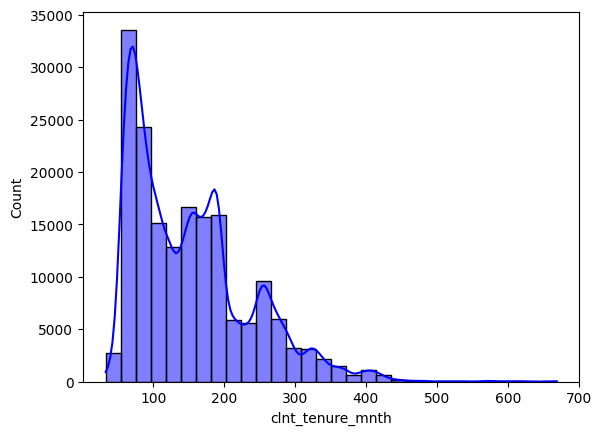

In [35]:
fig, axes = plt.subplots()
sns.histplot(client_test['clnt_tenure_mnth'], kde=True, bins=30, color="blue", ax=axes);
plt.show()

The histogram shows a right-skewed, with three visible peaks around 75, 175, and 260 months. This suggests the client base isn't uniform there are distinct "waves" of clients who joined at different periods.

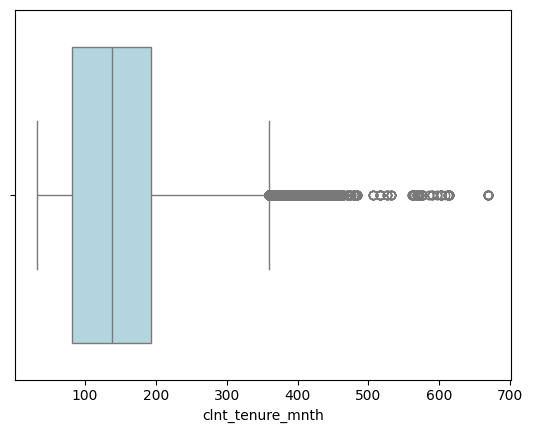

In [36]:
sns.boxplot(x = client_test['clnt_tenure_mnth'], color="lightblue");

The boxplot makes it clear there's a long right tail with many outliers beyond 350 months, going up to 670 months (56 years). These are very long-standing clients but relatively few in number.

**New vs. Long-standing?**
These are predominantly long-standing clients. A seniority of 134 months median means the typical client has been with Vanguard for nearly a decade. Very few clients are new, the left tail starts around 50–60 months (4-5 years minimum in the test group).

## 1. COMPLETION RATE: The proportion of users who reach the final 'confirm' step.

In [37]:
test_df.columns=[str(col).lower()for col in test_df.columns]
test_df.columns

Index(['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time',
       'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts',
       'bal', 'calls_6_mnth', 'logons_6_mnth', 'variation'],
      dtype='str')

In [38]:
test_df.to_csv('../data/test_clients.csv')

In [39]:
test_df.process_step.value_counts()

process_step
start      55773
step_1     38666
step_2     30899
step_3     25761
confirm    25600
Name: count, dtype: int64

In [40]:
# This is showing the percentage out of the total number of transactions how many were 'confirm' but this doesn't equate the proportion
# of clients who reached this step as there are more steps done than unique client_ids' (clients do more than one step).
test_df.process_step.value_counts(normalize=True)

process_step
start      0.315638
step_1     0.218824
step_2     0.174868
step_3     0.145790
confirm    0.144879
Name: proportion, dtype: float64

### 1.1. Completion rate by client_id

In [41]:
test_df.shape

(176699, 14)

In [42]:
# Number of clients who participated in the test meassured through unique client_id:
total_clients=test_df.client_id.nunique()
total_clients

26968

In [43]:
# Number of clients who reached 'confirm' through unique client id:
completed_clients=test_df.loc[test_df['process_step'] == 'confirm','client_id'].nunique()
completed_clients

18687

In [44]:
#  Proportion of clients who reach the final 'confirm' step.
completion_rate= completed_clients/total_clients
print(f'The percentage of clients in the test that completed the process was: {round(completion_rate*100,2)}% .')

The percentage of clients in the test that completed the process was: 69.29% .


In [45]:
# Has any client completed the process more than once, so they have 'confirm' twice??
confirm_counts = (test_df[test_df['process_step'] == 'confirm'].groupby('client_id').size().sort_values(ascending=False))

confirm_counts.head(10)

client_id
465007     19
8290360    17
8047921    17
1637369    17
7818040    16
4719244    16
5835400    15
3840915    14
9286288    14
3250123    14
dtype: int64

In [46]:
# Number of clients who completed the process more than once:
multiple_clients=(confirm_counts > 1).sum()
multiple_clients

np.int64(3818)

In [47]:
# proportion of clients who comleted the process more than once:
multiple_compl_rate= multiple_clients/total_clients
print(f'The percentage of clients who finished the process more than once was: {round(multiple_compl_rate*100,2)}% .')

The percentage of clients who finished the process more than once was: 14.16% .


### 1.2. Completion rate by visit_id

In [48]:
# Number of users who participated in the test meassured through unique visit_id:
total_users=test_df.visit_id.nunique()
total_users

37136

In [49]:
# Number of users who reached 'confirm' through unique visit_id:
completed_users=test_df.loc[test_df['process_step'] == 'confirm','visit_id'].nunique()
completed_users

21731

In [50]:
#  Proportion of users who reach the final 'confirm' step.
completion_rate_user= completed_users/total_users
print(f'The percentage of users in the test that completed the process was: {round(completion_rate_user*100,2)}% .')

The percentage of users in the test that completed the process was: 58.52% .


In [51]:
# Has any user completed the process more than once, so they have 'confirm' twice??
confirm_counts_user = (test_df[test_df['process_step'] == 'confirm'].groupby('visit_id').size().sort_values(ascending=False))

confirm_counts_user.head(10)

visit_id
155305468_93296256914_310722    11
820090283_58581376462_851669    10
888059775_41615184565_735869     9
50537501_11478756856_509628      9
909542137_43776543875_270909     8
460554742_28400086692_520981     8
844228903_71694336225_54897      8
192610287_73139264154_785164     8
533429166_8203298244_391770      8
171083873_3756289961_109356      8
dtype: int64

In [52]:
# Number of users who completed the process more than once:
multiple_users=(confirm_counts_user > 1).sum()
multiple_users

np.int64(2826)

In [53]:
# proportion of users who comleted the process more than once:
users_multicompl_rate= multiple_users/total_users
print(f'The percentage of users who finished the process more than once was: {round(users_multicompl_rate*100,2)}% .')

The percentage of users who finished the process more than once was: 7.61% .


## 2. Errors:  users go back to a previous step

In [54]:
test_df.dtypes

client_id             int64
visitor_id              str
visit_id                str
process_step            str
date_time               str
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gendr                   str
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
variation               str
dtype: object

In [55]:
test_df.date_time=pd.to_datetime(test_df['date_time'])
test_df.date_time

0        2017-04-17 15:27:07
1        2017-04-17 15:26:51
2        2017-04-17 15:19:22
3        2017-04-17 15:19:13
4        2017-04-17 15:18:04
                 ...        
629299   2017-05-06 23:51:05
629300   2017-05-06 23:50:40
629301   2017-05-06 23:43:47
629302   2017-05-06 23:43:34
629303   2017-05-06 23:43:27
Name: date_time, Length: 176699, dtype: datetime64[us]

In [56]:
test_date=test_df.date_time.loc[0]-test_df.date_time.loc[1]
test_date

Timedelta('0 days 00:00:16')

In [57]:
test_df.process_step.value_counts()

process_step
start      55773
step_1     38666
step_2     30899
step_3     25761
confirm    25600
Name: count, dtype: int64

In [58]:
# Convert categorical values to numerical in 'process_step' column:
steps_map={'start':0, 'step_1':1, 'step_2':2, 'step_3':3, 'confirm':4}

test_df['step_num']= test_df['process_step'].map(steps_map)

test_df.step_num.value_counts()

step_num
0    55773
1    38666
2    30899
3    25761
4    25600
Name: count, dtype: int64

In [59]:
test_df.head()

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,step_num
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test,3
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test,2
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test,3
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test,2
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test,3


In [60]:
# keep only relevant column for checking error and sort by visit and date so the steps are supposed to be sequential:
test_error= test_df[['client_id', 'visit_id', 'process_step','step_num','date_time']]
test_error=test_error.sort_values(['client_id','visit_id', 'date_time'], ascending=True)
test_error.head(20)
test_error.info()

<class 'pandas.DataFrame'>
Index: 176699 entries, 71583 to 354471
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     176699 non-null  int64         
 1   visit_id      176699 non-null  str           
 2   process_step  176699 non-null  str           
 3   step_num      176699 non-null  int64         
 4   date_time     176699 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 8.1 MB


In [61]:
# Visit ids suspected to not be unique, there could be a visit id asigned to more than one client:
visit_client_check = (test_df.groupby('visit_id')['client_id'].nunique().reset_index(name='n_clients'))

problem_visits = visit_client_check[visit_client_check['n_clients'] > 1]

problem_visits

,visit_id,n_clients
528,112254779_47535940518_581091,2
779,117770016_4680826099_368060,2
935,121772198_75922258840_579729,2
1619,138540908_31447989059_850186,2
2783,1665553_36655400041_536719,2
...,...,...
35111,951082863_24678579361_211427,2
35566,962361876_81235678513_401571,2
35894,970954907_53477955559_980080,2
36362,98225168_59624005396_471552,2


In [62]:
# Checking to see examples of repeated visit ids for different clients:
error_rows = test_df[test_df['visit_id'].isin(problem_visits['visit_id'])]

error_rows = error_rows[['client_id', 'visit_id', 'process_step', 'step_num', 'date_time']].sort_values(['visit_id', 'client_id', 'date_time'])

error_rows.head(40)

,client_id,visit_id,process_step,step_num,date_time
202216,3351731,112254779_47535940518_581091,start,0,2017-04-12 12:42:08
202215,3351731,112254779_47535940518_581091,step_1,1,2017-04-12 12:42:11
202214,3351731,112254779_47535940518_581091,step_2,2,2017-04-12 12:42:25
202213,3351731,112254779_47535940518_581091,step_3,3,2017-04-12 12:42:38
202212,3351731,112254779_47535940518_581091,confirm,4,2017-04-12 12:42:54
40974,4543944,112254779_47535940518_581091,start,0,2017-04-12 12:35:37
40973,4543944,112254779_47535940518_581091,start,0,2017-04-12 12:37:03
40972,4543944,112254779_47535940518_581091,step_1,1,2017-04-12 12:40:01
40971,4543944,112254779_47535940518_581091,step_2,2,2017-04-12 12:40:21
40970,4543944,112254779_47535940518_581091,step_3,3,2017-04-12 12:40:57


In [63]:
# Create a function to identify the errors (we consider an error everytime the succesion of the client isn't from one step to the next):

def bool_error(series):
    return (series.diff() <= 0) # <= because repeating a step means there's an error

In [64]:
# Create new column with the errors in boolean form by using the previously defined function:
test_error['error'] = test_error.groupby(['client_id','visit_id'])['step_num'].transform(bool_error)
test_error.head(20)
test_error.info()

<class 'pandas.DataFrame'>
Index: 176699 entries, 71583 to 354471
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     176699 non-null  int64         
 1   visit_id      176699 non-null  str           
 2   process_step  176699 non-null  str           
 3   step_num      176699 non-null  int64         
 4   date_time     176699 non-null  datetime64[us]
 5   error         176699 non-null  bool          
dtypes: bool(1), datetime64[us](1), int64(2), str(2)
memory usage: 8.3 MB


In [65]:
test_error['error']=test_error.error.astype(int)
test_error.head(20)
test_error['date_time'].isna().sum()

np.int64(0)

In [66]:
n_test_error=test_error.error.sum()
n_test_error

np.int64(35248)

In [67]:
pct_error_test=n_test_error/len(test_error)
print(f'The percentage of actions in the process that were errors was: {round(pct_error_test*100,2)}% . ')

The percentage of actions in the process that were errors was: 19.95% . 


## 3. Duration: average time users take to finish a step
test_error['date_time'] = pd.to_datetime(
    test_error['date_time']
)

In [68]:
# HEAD
test_error['duration']=test_error.groupby("visit_id").date_time.diff()
test_error['duration_sec'] = test_error['duration'].dt.total_seconds()

#
test_error['duration']=test_error.groupby(['client_id','visit_id']).date_time.diff()
# main
test_error.head(20)

,client_id,visit_id,process_step,step_num,date_time,error,duration,duration_sec
71583,555,637149525_38041617439_716659,start,0,2017-04-15 12:57:56,0,NaT,NaN
71582,555,637149525_38041617439_716659,step_1,1,2017-04-15 12:58:03,0,0 days 00:00:07,7.0
71581,555,637149525_38041617439_716659,step_2,2,2017-04-15 12:58:35,0,0 days 00:00:32,32.0
71580,555,637149525_38041617439_716659,step_3,3,2017-04-15 13:00:14,0,0 days 00:01:39,99.0
71579,555,637149525_38041617439_716659,confirm,4,2017-04-15 13:00:34,0,0 days 00:00:20,20.0
137375,647,40369564_40101682850_311847,start,0,2017-04-12 15:41:28,0,NaT,NaN
137374,647,40369564_40101682850_311847,step_1,1,2017-04-12 15:41:35,0,0 days 00:00:07,7.0
137373,647,40369564_40101682850_311847,step_2,2,2017-04-12 15:41:53,0,0 days 00:00:18,18.0
137372,647,40369564_40101682850_311847,step_3,3,2017-04-12 15:45:02,0,0 days 00:03:09,189.0
137369,647,40369564_40101682850_311847,confirm,4,2017-04-12 15:47:45,0,0 days 00:02:43,163.0


In [69]:
(len(test_error) - test_error['visit_id'].nunique()) == test_error['duration_sec'].count()
print(len(test_error))
print(test_error['visit_id'].nunique())
print(test_error['duration_sec'].count())

176699
37136
139563


In [70]:
test_error.info()
test_error[
    test_error.duplicated(
        ['visit_id','date_time'],
        keep=False
    )
].shape

<class 'pandas.DataFrame'>
Index: 176699 entries, 71583 to 354471
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype          
---  ------        --------------   -----          
 0   client_id     176699 non-null  int64          
 1   visit_id      176699 non-null  str            
 2   process_step  176699 non-null  str            
 3   step_num      176699 non-null  int64          
 4   date_time     176699 non-null  datetime64[us] 
 5   error         176699 non-null  int64          
 6   duration      139495 non-null  timedelta64[us]
 7   duration_sec  139563 non-null  float64        
dtypes: datetime64[us](1), float64(1), int64(3), str(2), timedelta64[us](1)
memory usage: 12.1 MB


(390, 8)

In [71]:
step_avg=test_error.groupby('step_num').duration_sec.mean()

In [72]:
step_avg

step_num
0    150.237895
1     37.804657
2     48.272585
3     97.356255
4    129.387486
Name: duration_sec, dtype: float64

In [73]:
step_error=test_error[test_error['error']==0].groupby('step_num').duration.mean()

In [191]:
step_error

step_num
0                      NaT
1   0 days 00:00:31.071368
2   0 days 00:00:37.125825
3   0 days 00:01:26.400487
4   0 days 00:01:45.083631
Name: duration, dtype: timedelta64[us]

In [75]:
len(test_error[test_error['error']==0])

141451

# CONTROL CLIENTS KPI ANALYSIS 

In [76]:
control_df=experiment[experiment['Variation'] == 'Control']
control_df.head()

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
13,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:03,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control
14,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:01,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control
15,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:28:52,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control
16,4033851,762728880_76361333336,949661017_22392791362_127391,step_3,2017-04-05 12:26:08,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control
17,4033851,762728880_76361333336,949661017_22392791362_127391,step_2,2017-04-05 12:24:43,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control


In [77]:
control_df.shape

(140536, 14)

In [78]:
control_df.isna().sum()

client_id            0
visitor_id           0
visit_id             0
process_step         0
date_time            0
clnt_tenure_yr      42
clnt_tenure_mnth    42
clnt_age            54
gendr               42
num_accts           42
bal                 42
calls_6_mnth        42
logons_6_mnth       42
Variation            0
dtype: int64

In [79]:
control_df.duplicated().sum()

np.int64(0)

## 1. Completion rate

### 1.1.Completion rate by client_id

In [80]:
total_cclients=control_df.client_id.nunique()
total_cclients

23532

In [81]:
# Number of clients who reached 'confirm' through unique client id:
completed_cclients=control_df.loc[control_df['process_step'] == 'confirm','client_id'].nunique()
completed_cclients

15434

In [82]:
#  Proportion of clients who reach the final 'confirm' step.
ccompletion_rate= completed_cclients/total_cclients
print(f'The percentage of clients in the control that completed the process was: {round(ccompletion_rate*100,2)}% .')

The percentage of clients in the control that completed the process was: 65.59% .


### 1.2. Completion rate by visit_id

In [83]:
# Number of users who participated in the test meassured through unique visit_id:
total_cusers=control_df.visit_id.nunique()
total_cusers

32189

In [84]:
# Number of users who reached 'confirm' through unique visit_id:
completed_cusers=test_df.loc[test_df['process_step'] == 'confirm','visit_id'].nunique()
completed_cusers

21731

In [85]:
#  Proportion of users who reach the final 'confirm' step.
completion_rate_cuser= completed_cusers/total_cusers
print(f'The percentage of users in the control that completed the process was: {round(completion_rate_cuser*100,2)}% .')

The percentage of users in the control that completed the process was: 67.51% .


## 2. Errors:  users go back to a previous step

In [86]:
control_df.date_time=pd.to_datetime(control_df['date_time'])
control_df.date_time

13       2017-04-05 12:29:03
14       2017-04-05 12:29:01
15       2017-04-05 12:28:52
16       2017-04-05 12:26:08
17       2017-04-05 12:24:43
                 ...        
629289   2017-05-13 15:30:47
629346   2017-05-10 22:57:17
629347   2017-05-10 22:56:31
629348   2017-05-10 22:56:23
629349   2017-05-10 22:56:20
Name: date_time, Length: 140536, dtype: datetime64[us]

In [87]:
control_df.process_step.value_counts()

process_step
start      45380
step_1     29544
step_2     25773
step_3     22503
confirm    17336
Name: count, dtype: int64

In [88]:
# Convert categorical values to numerical in 'process_step' column:
steps_map={'start':0, 'step_1':1, 'step_2':2, 'step_3':3, 'confirm':4}

control_df['step_num']= control_df['process_step'].map(steps_map)

control_df.step_num.value_counts()

step_num
0    45380
1    29544
2    25773
3    22503
4    17336
Name: count, dtype: int64

In [89]:
# keep only relevant column for checking error and sort by visit and date so the steps are supposed to be sequential:
control_error=control_df[['client_id', 'visit_id', 'process_step','step_num','date_time']]
control_error=control_error.sort_values(['client_id','visit_id', 'date_time'], ascending=True)
control_error.head(20)

,client_id,visit_id,process_step,step_num,date_time
131606,1028,557292053_87239438319_391157,start,0,2017-04-08 18:51:28
131605,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:52:17
131604,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:53:20
131603,1028,557292053_87239438319_391157,step_2,2,2017-04-08 18:53:29
131602,1028,557292053_87239438319_391157,step_3,3,2017-04-08 18:58:04
131601,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:59:55
131600,1028,557292053_87239438319_391157,step_1,1,2017-04-08 19:00:15
131599,1028,557292053_87239438319_391157,step_2,2,2017-04-08 19:00:17
131598,1028,557292053_87239438319_391157,step_1,1,2017-04-08 19:00:26
374551,1104,543158812_46395476577_767725,start,0,2017-06-12 07:49:18


In [90]:
# Visit ids suspected to not be unique, there could be a visit id asigned to more than one client:
visit_client_ccheck = (control_error.groupby('visit_id')['client_id'].nunique().reset_index(name='n_clients'))

problem_visits_control = visit_client_ccheck[visit_client_ccheck['n_clients'] > 1]
display(problem_visits_control)
print(len(problem_visits_control))

,visit_id,n_clients
1066,130502763_87279132515_340748,2
1479,141743147_36590758322_729214,2
1711,147972690_17593388107_595987,2
1897,153139550_16224196740_395856,2
2082,158589647_80114757716_717530,2
2952,183140897_9382261190_973385,2
3322,193051099_27203058364_390971,2
4484,223810870_31774647961_65837,2
4599,227481616_93925683177_231473,2
4738,231273005_71853417403_716422,2


54


In [91]:
# function to identify errors:

def bool_error(series):
    return (series.diff() <= 0) #only < if we don't consider repeating a step an error, <= if repeating a step means there's an error

In [92]:
# new column with errors in boolean form:
control_error['error'] = control_error.groupby(['client_id','visit_id'])['step_num'].transform(bool_error)
control_error.head(20)

,client_id,visit_id,process_step,step_num,date_time,error
131606,1028,557292053_87239438319_391157,start,0,2017-04-08 18:51:28,False
131605,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:52:17,False
131604,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:53:20,True
131603,1028,557292053_87239438319_391157,step_2,2,2017-04-08 18:53:29,False
131602,1028,557292053_87239438319_391157,step_3,3,2017-04-08 18:58:04,False
131601,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:59:55,True
131600,1028,557292053_87239438319_391157,step_1,1,2017-04-08 19:00:15,True
131599,1028,557292053_87239438319_391157,step_2,2,2017-04-08 19:00:17,False
131598,1028,557292053_87239438319_391157,step_1,1,2017-04-08 19:00:26,True
374551,1104,543158812_46395476577_767725,start,0,2017-06-12 07:49:18,False


In [93]:
control_error['error']=control_error.error.astype(int)
control_error.head(20)

,client_id,visit_id,process_step,step_num,date_time,error
131606,1028,557292053_87239438319_391157,start,0,2017-04-08 18:51:28,0
131605,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:52:17,0
131604,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:53:20,1
131603,1028,557292053_87239438319_391157,step_2,2,2017-04-08 18:53:29,0
131602,1028,557292053_87239438319_391157,step_3,3,2017-04-08 18:58:04,0
131601,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:59:55,1
131600,1028,557292053_87239438319_391157,step_1,1,2017-04-08 19:00:15,1
131599,1028,557292053_87239438319_391157,step_2,2,2017-04-08 19:00:17,0
131598,1028,557292053_87239438319_391157,step_1,1,2017-04-08 19:00:26,1
374551,1104,543158812_46395476577_767725,start,0,2017-06-12 07:49:18,0


In [94]:
n_control_errors= control_error.error.sum()
n_control_errors

np.int64(23255)

In [95]:
pct_error=n_control_errors/len(control_error)
print(f'The percentage of actions in the process that were errors was: {round(pct_error*100,2)}% . ')

The percentage of actions in the process that were errors was: 16.55% . 


In [96]:
# Counting how many visits had errors:
total_visits_control=control_error.visit_id.nunique
print(total_visits_control)
#visits_with_erors= 

<bound method IndexOpsMixin.nunique of 131606    557292053_87239438319_391157
131605    557292053_87239438319_391157
131604    557292053_87239438319_391157
131603    557292053_87239438319_391157
131602    557292053_87239438319_391157
                      ...             
118839    189177304_69869411700_783154
118838    189177304_69869411700_783154
118836    189177304_69869411700_783154
118837    189177304_69869411700_783154
118473      378424178_59565976155_8051
Name: visit_id, Length: 140536, dtype: str>


## 3. Duration

In [97]:
control_error['duration']=control_error.groupby((['client_id','visit_id'])).date_time.diff()
control_error.head(20)

,client_id,visit_id,process_step,step_num,date_time,error,duration
131606,1028,557292053_87239438319_391157,start,0,2017-04-08 18:51:28,0,NaT
131605,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:52:17,0,0 days 00:00:49
131604,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:53:20,1,0 days 00:01:03
131603,1028,557292053_87239438319_391157,step_2,2,2017-04-08 18:53:29,0,0 days 00:00:09
131602,1028,557292053_87239438319_391157,step_3,3,2017-04-08 18:58:04,0,0 days 00:04:35
131601,1028,557292053_87239438319_391157,step_1,1,2017-04-08 18:59:55,1,0 days 00:01:51
131600,1028,557292053_87239438319_391157,step_1,1,2017-04-08 19:00:15,1,0 days 00:00:20
131599,1028,557292053_87239438319_391157,step_2,2,2017-04-08 19:00:17,0,0 days 00:00:02
131598,1028,557292053_87239438319_391157,step_1,1,2017-04-08 19:00:26,1,0 days 00:00:09
374551,1104,543158812_46395476577_767725,start,0,2017-06-12 07:49:18,0,NaT


In [98]:
control_avg=control_error.groupby('step_num').duration.mean()
control_avg

step_num
0   0 days 00:02:54.667587
1   0 days 00:00:43.180969
2   0 days 00:00:38.838146
3   0 days 00:01:34.159650
4   0 days 00:02:09.976828
Name: duration, dtype: timedelta64[us]

In [99]:
control_noerror_avg=control_error[control_error['error']==0].groupby('step_num').duration.mean()
control_noerror_avg

step_num
0                      NaT
1   0 days 00:00:37.639736
2   0 days 00:00:33.827217
3   0 days 00:01:28.301364
4   0 days 00:02:07.561599
Name: duration, dtype: timedelta64[us]

# COMPARISON: test group vs control group

In [100]:
# Completion rate (out of client id or visit id):
print(f'The completion rate for clients in the TEST group: {round(completion_rate*100,2)}% .')
print(f'The completion rate for clients in the CONTROL group: {round(ccompletion_rate*100,2)}% .')

The completion rate for clients in the TEST group: 69.29% .
The completion rate for clients in the CONTROL group: 65.59% .


In [101]:
# Error rate (out of all transactions or visits?): 
print(f'The error rate per action in the website for the TEST group: {round(pct_error_test*100,2)}% . ')
print(f'The error rate per action in the website for the CONTROL group: {round(pct_error*100,2)}% . ')

The error rate per action in the website for the TEST group: 19.95% . 
The error rate per action in the website for the CONTROL group: 16.55% . 


h0=completion rate test group is 5% > completion rate control group
h1=completion rate test group is 5% <= completion rate control group

statistic Z=p1-p2-d/sqrt
p-value=
a=0,05 IC=

hypothesis for completion rate
hypotheis for mean duration (two samples t-test) 

# HYPOTHESIS TESTING

## 1. Completion rate

### **TEST 1: Difference in the completion rates** 

We want to know whether the **TEST group has a higher completion rate than the CONTROL group**.

We will perform a one tailed Z-test with the rejection area to the left:

- H0: completion rate test group >= completion rate control group
- H1: completion rate test group < completion rate control group

alpha = 0.05

In [102]:
# H1: p1 < p2
alpha = 0.05
z_stat_sm, p_value_sm = proportions_ztest(count = [completed_clients, completed_cclients],nobs  = [total_clients, total_cclients]
, alternative='smaller')

print(f'Z-statistic: {z_stat_sm}')
print(f'p-value: {p_value_sm}')

Z-statistic: 8.8745141890702
p-value: 1.0


**Conclusions:**
After running a one-tailed two-proportion Z-test at α = 0.05:
- The p-value was above 0.05, so we **accept H₀**:
- The TEST group has a **statistically significantly higher** completion rate than the CONTROL group.

In [103]:
def show_statistical_test(statistic: float, alpha: float, n: int, distribution: str=["t-student","normal"], alternative: str=["two-sided","lower","greater"]):

    if distribution not in ["t-student","normal"]:
        raise TypeError("Sorry, only 't-student', and 'normal' distributions are acepted")

    if alternative not in ["two-sided","lower","greater"]:
        raise TypeError("Sorry, only 'two-sided', 'lower', and 'greated' are acepted valued for the alternative")

    if not isinstance(statistic, float):
        raise TypeError("Sorry, the data type for the statistic must be float")

    if not isinstance(alpha, float):
        raise TypeError("Sorry, the data type for alpha must be float")

    if not isinstance(n, int):
        raise TypeError("Sorry, the data type for n must be int")

    x_values = np.linspace(-3, 3)

    if distribution == "t-student":

        y_values = st.t.pdf(x_values, df=n-1)

        if alternative == "two-sided": # Computing the critical values

            lower_critical_value = st.t.ppf(alpha/2, df=n-1)
            upper_critical_value = st.t.ppf(1-(alpha/2), df=n-1)

            x_values1 = np.linspace(-3, lower_critical_value)
            y_values1 = st.t.pdf(x_values1, df=n-1)

            x_values2 = np.linspace(upper_critical_value, 3)
            y_values2 = st.t.pdf(x_values2, df=n-1)

        elif alternative == "lower":

            critical_value = st.t.ppf(alpha, df=n-1)

            x_values1 = np.linspace(-3, critical_value)
            y_values1 = st.t.pdf(x_values1, df=n-1)

        elif alternative == "greater":

            critical_value = st.t.ppf(1-alpha, df=n-1)

            x_values2 = np.linspace(critical_value, 3)
            y_values2 = st.t.pdf(x_values2, df=n-1)

    elif distribution == "normal":

        y_values = st.norm.pdf(x_values)

        if alternative == "two-sided": # Computing the critical values

            lower_critical_value = st.norm.ppf(alpha/2)
            upper_critical_value = st.norm.ppf(1-(alpha/2))

            x_values1 = np.linspace(-3, lower_critical_value)
            y_values1 = st.norm.pdf(x_values1)

            x_values2 = np.linspace(upper_critical_value, 3)
            y_values2 = st.norm.pdf(x_values2)

        elif alternative == "lower":

            critical_value = st.norm.ppf(alpha)

            x_values1 = np.linspace(-3, critical_value)
            y_values1 = st.norm.pdf(x_values1)

        elif alternative == "greater":

            critical_value = st.norm.ppf(1-alpha)

            x_values2 = np.linspace(critical_value, 3)
            y_values2 = st.norm.pdf(x_values2)

    df = pd.DataFrame({"x": x_values, "pdf": y_values})

    title = f"{distribution} Probability Density Function"

    fig = px.line(df, x="x", y="pdf", title=title)

    if alternative == "two-sided":

        fig.add_vline(x=lower_critical_value, line_color="red")
        fig.add_vline(x=upper_critical_value, line_color="red")

        fig.add_annotation(x=lower_critical_value,y=0,text=f"Lower critical value {lower_critical_value: .2f}",xref="x",yref="paper",yanchor="bottom")
        fig.add_annotation(x=upper_critical_value,y=0,text=f"Upper critical value {upper_critical_value: .2f}",xref="x",yref="paper",yanchor="bottom")

        fig.add_scatter(x=x_values1, y=y_values1,fill='tozeroy', mode='none' , fillcolor='red')
        fig.add_scatter(x=x_values2, y=y_values2,fill='tozeroy', mode='none' , fillcolor='red')

    elif alternative == "lower":

        fig.add_vline(x=critical_value, line_color="red")
        fig.add_annotation(x=critical_value,y=0,text=f"Critical value {critical_value: .2f}",xref="x",yref="paper",yanchor="bottom")

        fig.add_scatter(x=x_values1, y=y_values1,fill='tozeroy', mode='none' , fillcolor='red')

    elif alternative == "greater":

        fig.add_vline(x=critical_value, line_color="red")
        fig.add_annotation(x=critical_value,y=0,text=f"Critical value {critical_value: .2f}",xref="x",yref="paper",yanchor="bottom")

        fig.add_scatter(x=x_values2, y=y_values2,fill='tozeroy', mode='none' , fillcolor='red')

    fig.add_vline(x=statistic)
    fig.add_annotation(x=statistic,y=0,text=f"Statistic {statistic: .2f}",xref="x",yref="paper",yanchor="bottom")

    fig.update_layout(title_text=f'{distribution} Probability Density Function', title_x=0.5)

    fig.update_layout(showlegend=False)

    fig.show()

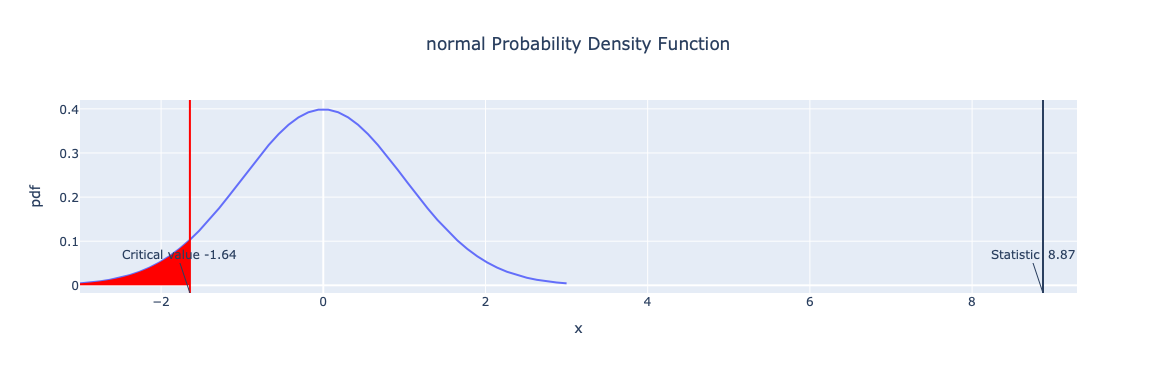

In [104]:
show_statistical_test(
    statistic=float(z_stat_sm),
    alpha=0.05,
    n=int(total_clients + total_cclients),
    distribution="normal",
    alternative="lower"
)

### **TEST 2: the difference in completion rates is above 0.05**

Now we will be testing whether the observed difference between the completion rates of the control and test group **meets a minimum  threshold** where **∂=0.05**. We are running a one-tailed two-proportion Z-test with the rejection area to the right. 

- H0 = completion rate test group - completion rate control group <= 0.05
- H1 = completion rate test group - completion rate control group > 0.05

alpha= 0.05
group_1=test_group
group_2=control_group


In [105]:
p1=completion_rate_user
p2=completion_rate_cuser
n1=total_clients
n2=total_cclients
p=(completed_clients+completed_cclients)/(n1+n2)
print(p)

0.6756633663366337


In [106]:
# Calculate the statistic Z manually using formula:
alpha=0.05
delta=0.05
Z=((p1-p2)-delta)/ np.sqrt(p * (1 - p) * ((1 / n1) + (1 / n2)))
print(f'Z={Z}')

Z=-33.50927363536048


In [107]:
# get the critical value using scipy stats:
df=n1+n2-2
cv=st.t.ppf(alpha,df)
print(f'CV={cv}')

CV=-1.644883802349942


In [108]:
def h0_test(z,cv):
    if z<cv:
        print('Reject H0')
    else:
        print('Accept H0')



In [109]:
h0_test(Z,cv)

Reject H0


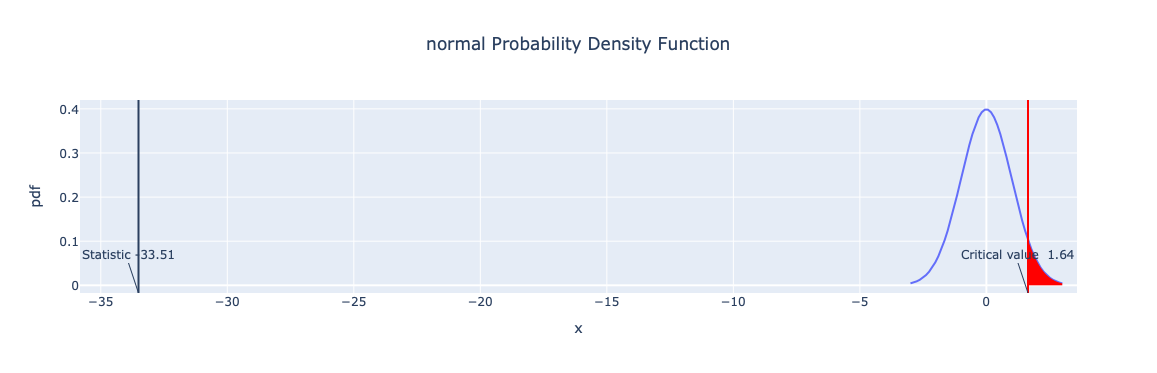

In [110]:
show_statistical_test(Z, alpha, df, distribution="normal", alternative="greater")

## 2. Duration 

T STUDENT DISTRIBUTION: two sided T-test. We're going to compare the means of the duration for each step in the test group vs control group.

- H0: avg step duration from TEST group = avg step duration from CONTROL group
- H1: avg step duration from TEST group != avg step duration from CONTROL group

Testing the average time without taking into account the errors, step by step.

### STEP 1

In [130]:
# create array for test and error only with step 1 times and no errors:

test_s1_df= test_error[(test_error['error'] == 0) &(test_error['step_num'] == 1)]['duration'].dt.total_seconds().dropna()

test_s1_mean=test_s1_df.mean()

control_s1_df= control_error[(control_error['error']==0) & (control_error['step_num']==1)]['duration'].dt.total_seconds().dropna()
control_s1_mean=control_s1_df.mean()
f'Test S1 mean: {test_s1_mean}, Control S1 mean:{control_s1_mean}'

'Test S1 mean: 31.071368622984235, Control S1 mean:37.63973612727978'

In [131]:
# STEP 1

x1= test_s1_mean
x2= control_s1_mean

n1=len(test_s1_df)
n2=len(control_s1_df)

s1=test_s1_df.std()
s2=control_s1_df.std()

print(f'x1: {x1}, x2: {x2}, n1: {n1}, n2: {n2}, s1: {s1}, s2: {s2}')

x1: 31.071368622984235, x2: 37.63973612727978, n1: 33362, n2: 25770, s1: 86.15639224852255, s2: 78.26266688125595


In [132]:
Tstatistic= (x1-x2)/np.sqrt((s1**2/n1)+ (s2**2/n2))
f'T-statistic: {Tstatistic}'

'T-statistic: -9.682660642553047'

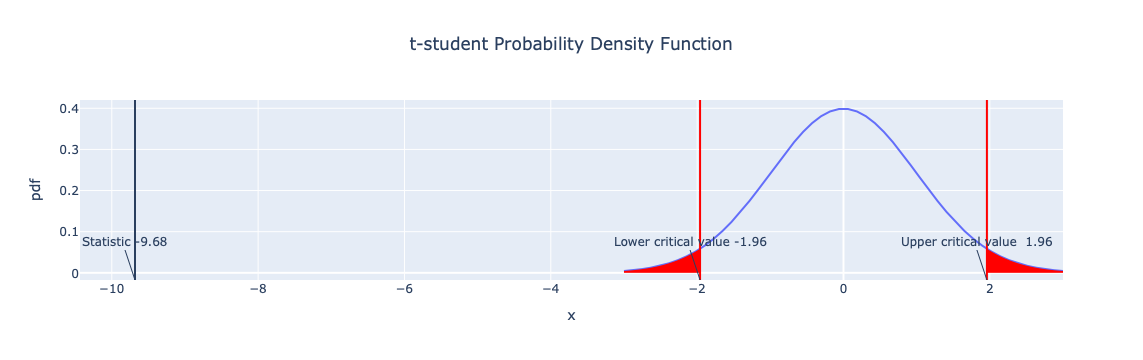

In [134]:
show_statistical_test(Tstatistic, 0.05, n1+n2-2, distribution="t-student", alternative="two-sided")

In [133]:
st.ttest_ind(test_s1_df, control_s1_df, equal_var=False, alternative="two-sided")

TtestResult(statistic=np.float64(-9.682660642553047), pvalue=np.float64(3.714725225441258e-22), df=np.float64(57604.390521954905))

We **reject H0** because the p-value is very small, smaller than alpha = 0.05. So we can say the test group and the control group didn't take the same amount of time to complete step1, actually the test group finished much quicker. 

### STEP 2

In [136]:
# Getting the necessary arrays of data to test the difference in duration in test and control group for STEP 2:
test_s2_df= test_error[(test_error['error'] == 0) &(test_error['step_num'] == 2)]['duration'].dt.total_seconds().dropna()

test_s2_mean=test_s2_df.mean()

control_s2_df= control_error[(control_error['error']==0) & (control_error['step_num']==2)]['duration'].dt.total_seconds().dropna()
control_s2_mean=control_s2_df.mean()
f'Test S2 mean: {test_s2_mean}, Control S2 mean:{control_s2_mean}'

'Test S2 mean: 37.125825437840945, Control S2 mean:33.827217670110436'

In [137]:
# calculating the necessary variables for the statistic T:
x12= test_s2_mean
x22= control_s2_mean

n12=len(test_s2_df)
n22=len(control_s2_df)

s12=test_s2_df.std()
s22=control_s2_df.std()

print(f'x1: {x12}, x2: {x22}, n1: {n12}, n2: {n22}, s1: {s12}, s2: {s22}')

x1: 37.125825437840945, x2: 33.827217670110436, n1: 27864, n2: 22456, s1: 58.81727592198995, s2: 53.61749848324688


In [138]:
# statistic for two tailed t student test calculated manually: 
Tstatistic2= (x12-x22)/np.sqrt((s12**2/n12)+ (s22**2/n22))
f'T-statistic: {Tstatistic2}'

'T-statistic: 6.568684562332209'

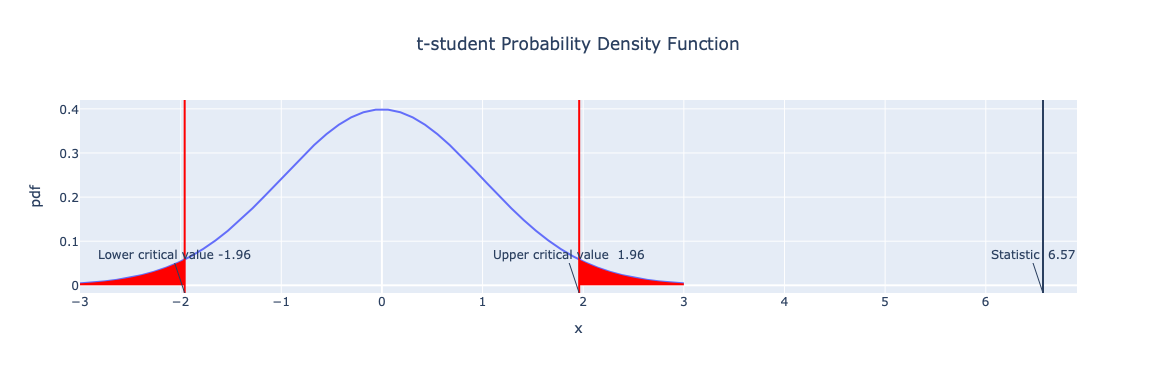

In [139]:
# graphical representation of the test + statistic + cv + rejection areas:
show_statistical_test(Tstatistic2, 0.05, n12+n22-2, distribution="t-student", alternative="two-sided")

In [140]:
# checking the manual calculations are correct using the scipy stats library: 
st.ttest_ind(test_s2_df, control_s2_df, equal_var=False, alternative="two-sided")

TtestResult(statistic=np.float64(6.568684562332209), pvalue=np.float64(5.1262432608401604e-11), df=np.float64(49561.83271529773))

In [145]:
# critical value through scipy stats:
st.t.ppf(q=1-0.05/2,df=n12+n22-2)

np.float64(1.9600111312335737)

We **reject H0** because the p-value is smaller than alpha=0.05, so the average duration of STEP 2 is different in the test group and the control group. The positive T value way above the CV indicates the test group actually took longer in average during this step.

### STEP 3

In [146]:
# Getting the necessary arrays of data to test the difference in duration in test and control group for STEP 2:
test_s3_df= test_error[(test_error['error'] == 0) &(test_error['step_num'] == 3)]['duration'].dt.total_seconds().dropna()
test_s3_mean=test_s3_df.mean()

control_s3_df= control_error[(control_error['error']==0) & (control_error['step_num']==3)]['duration'].dt.total_seconds().dropna()
control_s3_mean=control_s3_df.mean()

f'Test S3 mean: {test_s3_mean}, Control S3 mean:{control_s3_mean}'

'Test S3 mean: 86.40048790404553, Control S3 mean:88.30136412309697'

In [147]:
# calculating the necessary variables for the statistic T:
x13= test_s3_mean
x23= control_s3_mean

n13=len(test_s3_df)
n23=len(control_s3_df)

s13=test_s3_df.std()
s23=control_s3_df.std()

print(f'x1: {x13}, x2: {x23}, n1: {n13}, n2: {n23}, s1: {s13}, s2: {s23}')

x1: 86.40048790404553, x2: 88.30136412309697, n1: 24595, n2: 21479, s1: 86.7284679955673, s2: 91.49126139236668


In [148]:
# statistic for two tailed t student test calculated manually: 
Tstatistic3= (x13-x23)/np.sqrt((s13**2/n13)+ (s23**2/n23))
f'T-statistic: {Tstatistic3}'

'T-statistic: -2.2792530790724275'

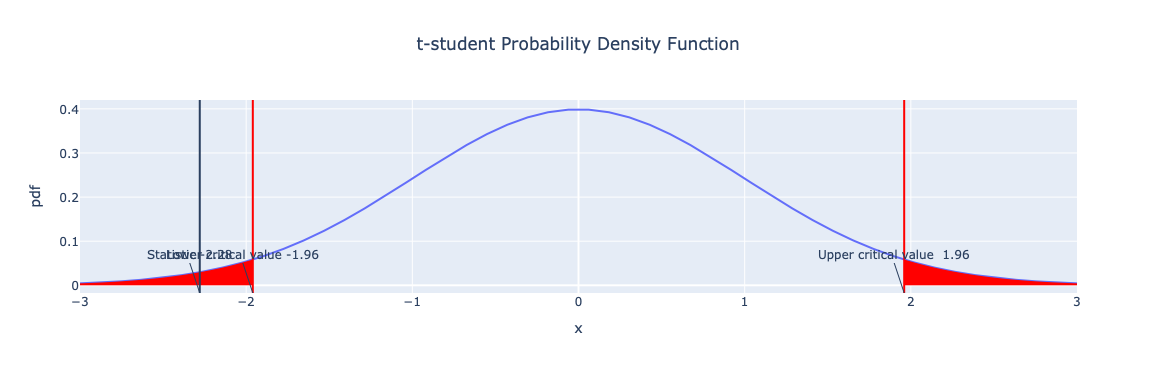

In [149]:
# graphical representation of the test + statistic + cv + rejection areas:
show_statistical_test(Tstatistic3, 0.05, n12+n22-2, distribution="t-student", alternative="two-sided")

In [150]:
# checking the manual calculations are correct using the scipy stats library: 
st.ttest_ind(test_s3_df, control_s3_df, equal_var=False, alternative="two-sided")

TtestResult(statistic=np.float64(-2.2792530790724275), pvalue=np.float64(0.022656739605635176), df=np.float64(44488.36929811586))

In [151]:
# critical value through scipy stats:
st.t.ppf(q=1-0.05/2,df=n13+n23-2)

np.float64(1.9600154763896434)

We **reject H0** because the p-value is smaller than alpha=0.05, so the average duration of STEP  is different in the test group and the control group. The negative T value below the CV indicates the control group actually took longer in average during this step.

### STEP 4

In [152]:
# Getting the necessary arrays of data to test the difference in duration in test and control group for STEP 4:
test_s4_df= test_error[(test_error['error'] == 0) &(test_error['step_num'] == 4)]['duration'].dt.total_seconds().dropna()
test_s4_mean=test_s4_df.mean()

control_s4_df= control_error[(control_error['error']==0) & (control_error['step_num']==4)]['duration'].dt.total_seconds().dropna()
control_s4_mean=control_s4_df.mean()

f'Test S4 mean: {test_s4_mean}, Control S4 mean:{control_s4_mean}'

'Test S4 mean: 105.08363182459568, Control S4 mean:127.56159916519924'

In [153]:
# calculating the necessary variables for the statistic T:
x14= test_s4_mean
x24= control_s4_mean

n14=len(test_s4_df)
n24=len(control_s4_df)

s14=test_s4_df.std()
s24=control_s4_df.std()

print(f'x1: {x14}, x2: {x24}, n1: {n14}, n2: {n24}, s1: {s14}, s2: {s24}')

x1: 105.08363182459568, x2: 127.56159916519924, n1: 18426, n2: 15333, s1: 160.1689037459632, s2: 155.34601244116806


In [154]:
# statistic for two tailed t student test calculated manually: 
Tstatistic4= (x14-x24)/np.sqrt((s14**2/n14)+ (s24**2/n24))
f'T-statistic: {Tstatistic4}'

'T-statistic: -13.051476682325625'

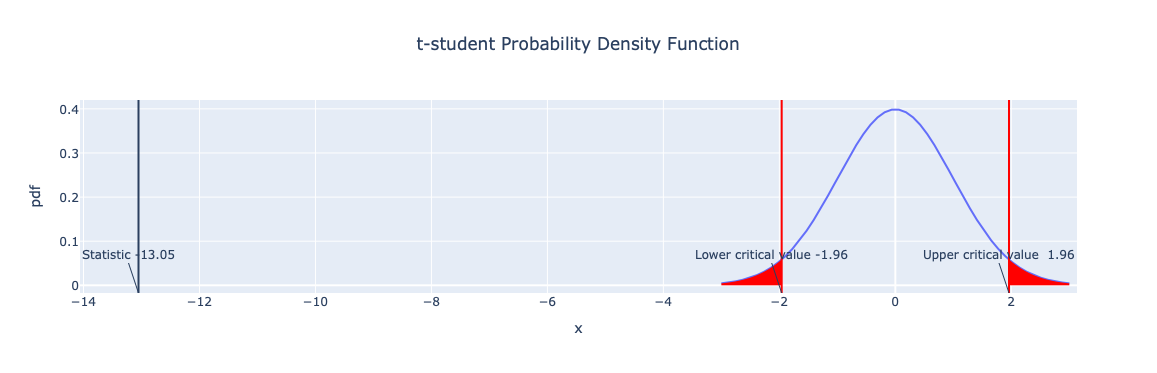

In [155]:
# graphical representation of the test + statistic + cv + rejection areas:
show_statistical_test(Tstatistic4, 0.05, n14+n24-2, distribution="t-student", alternative="two-sided")

In [156]:
# checking the manual calculations are correct using the scipy stats library: 
st.ttest_ind(test_s4_df, control_s4_df, equal_var=False, alternative="two-sided")

TtestResult(statistic=np.float64(-13.051476682325625), pvalue=np.float64(7.780215144883187e-39), df=np.float64(32979.93695889984))

In [157]:
# critical value through scipy stats:
st.t.ppf(q=1-0.05/2,df=n14+n24-2)

np.float64(1.9600342619593978)

We **reject H0** because the p-value is smaller than alpha=0.05, so the average duration of STEP 4 is different in the test group and the control group. The **negative T value** below the CV indicates the **control group took longer** in average during this step.

In [ ]:
ttest_ind(test_duration, control_duration, equal_var=False)

## 4. Conclusions

The **completion rate for the test group is higher** than for the control group which was the expected result and reason for the new UI.
However the second condition for this UI was not fulfilled, as **we cannot say that the completion rate of the test group is 5% above that of the control group**.

In terms of **average duration** for all 4 steps we *rejected H0* which means in all cases **the average duration for each step was never the same for the test group and control group**.
For step 2 the control group was faster in completing it and for all other tests the test group was faster which is good news in terms of the new interface as we need gto consider that it is the first time the users are interacting with it versus the control group were there is an experience bias as clients could have already interacted with the platform previously as it is the standing design.

# EXPERIMENT EVALUATION

In [162]:
# difference in number of clients in test group vs control group

nclients_test=experiment[experiment['Variation']=='Test']['client_id'].nunique()
nclients_group= experiment[experiment['Variation']=='Control']['client_id'].nunique()

f'The number of clients that participated in the test group was {nclients_test} and in the control group was: {nclients_group}'

'The number of clients that participated in the test group was 26968 and in the control group was: 23532'

This shows a bias in the experiment as the sample for the test group was bigger than the sample in the control group. Nor do both groups ahre the same characteristics?

In [192]:
age_clients_test=experiment[experiment['Variation']=='Test']['clnt_age'].mean()
age_clients_control=experiment[experiment['Variation']=='Control']['clnt_age'].mean()
f'The average age of the clients participating in the test group was: {age_clients_test}, and for the control group was: {age_clients_control}'

'The average age of the clients participating in the test group was: 48.72221624651129, and for the control group was: 48.284477726683846'

In [164]:
medage_clients_test=experiment[experiment['Variation']=='Test']['clnt_age'].median()
medage_clients_control=experiment[experiment['Variation']=='Control']['clnt_age'].median()
f'The median age of the clients participating in the test group was: {medage_clients_test}, and for the control group was: {medage_clients_control}'

'The median age of the clients participating in the test group was: 50.5, and for the control group was: 49.5'

The average age is so similar between groups it's negligible but there is a one year difference in the median. We could check the correlation between the age and the completion rate to see if this difference might be relevant and skewing the experiment. 

In [172]:
fem_clients_test=experiment[(experiment['Variation']=='Test')& (experiment['gendr']=='F')]['client_id'].nunique()/experiment[experiment['Variation']=='Test']['client_id'].nunique()
male_clients_test=experiment[(experiment['Variation']=='Test')& (experiment['gendr']=='M')]['client_id'].nunique()/experiment[experiment['Variation']=='Test']['client_id'].nunique()
fem_clients_control=experiment[(experiment['Variation']=='Control')& (experiment['gendr']=='F')]['client_id'].nunique()/experiment[experiment['Variation']=='Control']['client_id'].nunique()
male_clients_control=experiment[(experiment['Variation']=='Control')& (experiment['gendr']=='M')]['client_id'].nunique()/experiment[experiment['Variation']=='Control']['client_id'].nunique()

f'The percentage of female clients participating in the test group was: {round(fem_clients_test*100,2)}%, and for the control group was: {round(fem_clients_control*100,2)}%'

'The percentage of female clients participating in the test group was: 32.32%, and for the control group was: 32.05%'

The have an almost equal percentage proportion of female and male participants in the test and control groups so we can't say the experiment is biased in terms of gender distribution. There does however appear to be a gender bias in terms of the clients gender in general for vanguard, they should lokk into why they attratc such a small percentage of women.

In [179]:
male_clients_test*100, male_clients_control*100

(33.28760011865915, 33.868774434812174)

In [180]:
fem_clients=experiment[experiment['gendr']=='F']['client_id'].nunique()/experiment['client_id'].nunique()
male_clients=experiment[experiment['gendr']=='M']['client_id'].nunique()/experiment['client_id'].nunique()
other_clients=experiment[experiment['gendr']=='U']['client_id'].nunique()/experiment['client_id'].nunique()
f'The percentage of female clients of vanguard: {round(fem_clients*100,2)}%, of male clients: {round(male_clients*100,2)}% and of unknown gender: {round(other_clients*100,2)}%'

'The percentage of female clients of vanguard: 18.93%, of male clients: 19.74% and of unknown gender: 20.08%'

This quick chek on the gender distribution actually proves there is no issue with attracting female clients, in fact the distribution between female and male seems to be pretty equal there just seems to be a big amount of missing data unknown is 20% of the data, which complicates the analysis and makes these percentages unreliable.

In [181]:
tenure_clients_test=experiment[experiment['Variation']=='Test']['clnt_tenure_mnth'].mean()
tenure_clients_control=experiment[experiment['Variation']=='Control']['clnt_tenure_mnth'].mean()
f'The average tenure of the clients participating in the test group was: {tenure_clients_test}, and for the control group was: {tenure_clients_control}'

'The average tenure of the clients participating in the test group was: 152.22741039735962, and for the control group was: 152.00198584992953'

In [182]:
med_tenure_clients_test=experiment[experiment['Variation']=='Test']['clnt_tenure_mnth'].median()
med_tenure_clients_control=experiment[experiment['Variation']=='Control']['clnt_tenure_mnth'].median()
f'The median tenure of the clients participating in the test group was: {med_tenure_clients_test}, and for the control group was: {med_tenure_clients_control}'

'The median tenure of the clients participating in the test group was: 138.0, and for the control group was: 137.0'

Both groups have nearly identical average tenure of clients in months and median tenure so we cannot say there was any bias when splitting the groups in terms of selecting older or newer clients.

After analyzing the gender split, age and tenure of the clients in both groups we can confidently say the experiment was built with no biases as the characteristics of both groups are nearly identical, the only relevant difference would be the bigger size of the test group where more clients participated.

In [183]:
missing_val_test=experiment[experiment['Variation']=='Test'].isna().sum()
missing_val_control=experiment[experiment['Variation']=='Control'].isna().sum()
display(missing_val_test, missing_val_control)

client_id            0
visitor_id           0
visit_id             0
process_step         0
date_time            0
clnt_tenure_yr      58
clnt_tenure_mnth    58
clnt_age            58
gendr               58
num_accts           58
bal                 58
calls_6_mnth        58
logons_6_mnth       58
Variation            0
dtype: int64

client_id            0
visitor_id           0
visit_id             0
process_step         0
date_time            0
clnt_tenure_yr      42
clnt_tenure_mnth    42
clnt_age            54
gendr               42
num_accts           42
bal                 42
calls_6_mnth        42
logons_6_mnth       42
Variation            0
dtype: int64

In [190]:
prct_miss_val_test=experiment[(experiment['Variation'] == 'Test') &(experiment['gendr'].isna())]['client_id'].nunique()/experiment[experiment['Variation']=='Test']['client_id'].nunique()
prct_miss_val_control= experiment[(experiment['Variation'] == 'Control') &(experiment['gendr'].isna())]['client_id'].nunique()/experiment[experiment['Variation']=='Control']['client_id'].nunique()

f' The percentage of missing values for the test group: {round(prct_miss_val_test ,4)}% and the control group:{round(prct_miss_val_control ,4)}%.'

' The percentage of missing values for the test group: 0.0003% and the control group:0.0002%.'

The amount of missing values is negligible in both groups therefore we can say those missing values are not creating any noticeable bias.